# Exploratory Data Analysis
This notebook aims to explore and understand the dataset.

## Table of Contents

* [1. Import Data](#1-import-data)
    * [1.1 Importing Libraries](#11-importing-libraries)
    * [1.2 Importing Data](#12-importing-data)
* [2. Data Structure](#2-data-structure)
    * [2.1 Inspecting Data Structure](#21-insepcting-data-structure)
    * [2.2 Missing Value Checks](#22-missing-value-checks)
    * [2.3 Duplicates & Integrity Checks](#23-duplicates--integrity-checks)
* [3. Univariate Analysis](#3-univariate-analysis)
* [4. Bivariate Analysis](#4-bivariate-analysis)
* [_. Multicollinearity Checks](#_-multicollinearity-checks)


## 1. Import Data

### 1.1 Importing Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import display_side_by_side


print("loaded")

loaded


### 1.2 Importing Data

In [2]:
df = pd.read_csv("../data/raw_data/insurance_data.csv")

df.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


## 2. Data Structure

We aim to explore the dataset thoroughly in this section. We will manipulate the dataset accordingly, after the analysis, saving the copy the manipulated dataset for future use. 

### 2.1 Insepcting Data Structure

In [7]:
df

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [4]:
df.describe()

,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.000000,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.500000,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,0.000000,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,334.750000,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,669.500000,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1004.250000,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1339.000000,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [6]:
df.describe(include="all")

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1340.000000,1340.000000,1335.000000,1340,1340.000000,1340.000000,1340,1340.000000,1340,1337,1340.000000
unique,NaN,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,NaN,678,NaN,NaN,698,NaN,1066,443,NaN
mean,669.500000,670.500000,38.078652,NaN,30.668955,94.157463,NaN,1.093284,NaN,NaN,13252.745642
std,386.968991,386.968991,11.102924,NaN,6.106735,11.434712,NaN,1.205334,NaN,NaN,12109.609288
min,0.000000,1.000000,18.000000,NaN,16.000000,80.000000,NaN,0.000000,NaN,NaN,1121.870000
25%,334.750000,335.750000,29.000000,NaN,26.275000,86.000000,NaN,0.000000,NaN,NaN,4719.685000
50%,669.500000,670.500000,38.000000,NaN,30.400000,92.000000,NaN,1.000000,NaN,NaN,9369.615000
75%,1004.250000,1005.250000,47.000000,NaN,34.700000,99.000000,NaN,2.000000,NaN,NaN,16604.305000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


The dataset given in this project reflects a claim-level dataset, which each row represents one individual medical claim. The dataset has 1340 observations with 11 variables, `PatientID` being an unique ID and `claim` being the target variable. The datatypes of each variable is given above with `df.info()`. However, it makes more interpretable when `age` to be an integer, rather than a float.

### 2.2 Missing Value Checks

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


Examining the dataset, we see that there are a few missing values in `age` and `region`.

In [27]:
df[df['age'].isna() | df['region'].isna()]

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
5,5,6,NaN,male,34.4,96,Yes,0,No,northwest,1137.47
6,6,7,NaN,male,37.3,86,Yes,0,No,northwest,1141.45
13,13,14,32.0,male,27.6,100,No,0,No,NaN,1252.41
14,14,15,40.0,male,28.7,81,Yes,0,No,NaN,1253.94
15,15,16,32.0,male,30.4,86,Yes,0,No,NaN,1256.30


In [30]:
print(100*df['age'].isna().mean(),"%", 100*df['region'].isna().mean(),"%")

0.3731343283582089 % 0.22388059701492538 %


It looks like the missing values of each `age` and `region` takes up 0.4% and 0.2% of the sample size. Furthermore, although it is difficult to prove that the missing values are completely at random, they seem to be merely data entry errors. Hence, it is safe to drop these observations.

### 2.3 Duplicates & Integrity Checks

In [34]:
len(df['PatientID'].unique())

1340

`PatientID` can be used to see if there are any duplicates. Since unique ID has the same cardinality as the dataset (1340 observations), there are no duplicates present in the dataset.

In [60]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['index', 'PatientID'])
categorical_cols = df.select_dtypes(include='object').columns

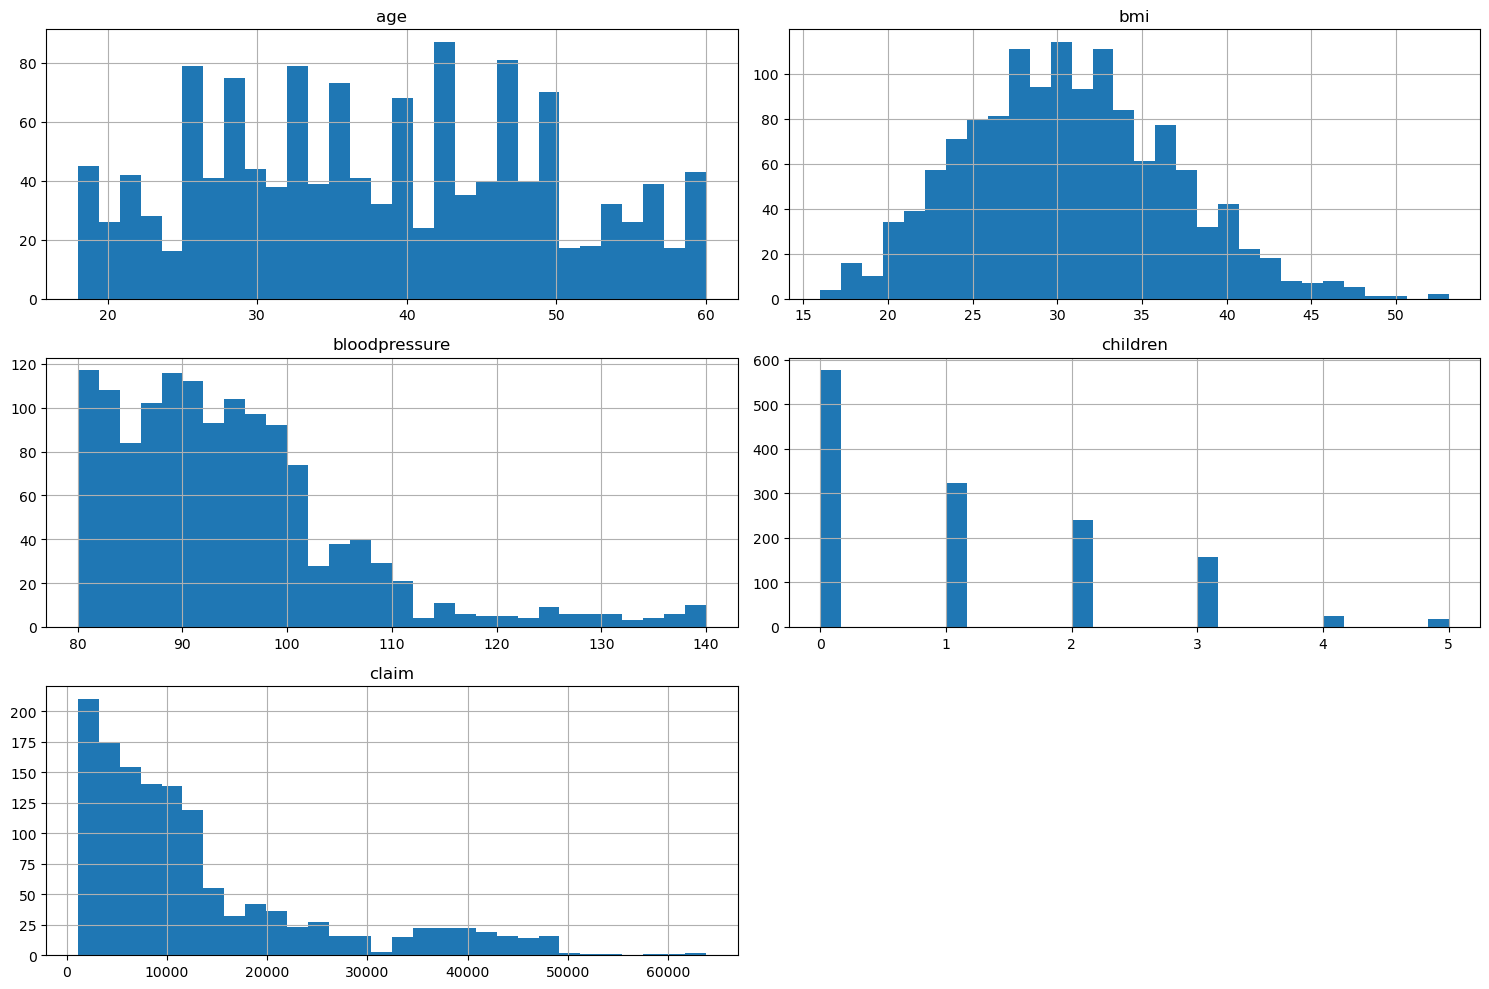

In [61]:
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

## 3. Univariate Analysis

## 4. Bivariate Analysis

## _. Multicollinearity Checks